----View the first few rows of the data---- 

         id diagnosis  radius_mean  texture_mean  perimeter_mean  area_mean  \
0    842302         M        17.99         10.38          122.80     1001.0   
1    842517         M        20.57         17.77          132.90     1326.0   
2  84300903         M        19.69         21.25          130.00     1203.0   
3  84348301         M        11.42         20.38           77.58      386.1   
4  84358402         M        20.29         14.34          135.10     1297.0   

   smoothness_mean  compactness_mean  concavity_mean  concave points_mean  \
0          0.11840           0.27760          0.3001              0.14710   
1          0.08474           0.07864          0.0869              0.07017   
2          0.10960           0.15990          0.1974              0.12790   
3          0.14250           0.28390          0.2414              0.10520   
4          0.10030           0.13280          0.1980              0.10430   

   ...  texture_

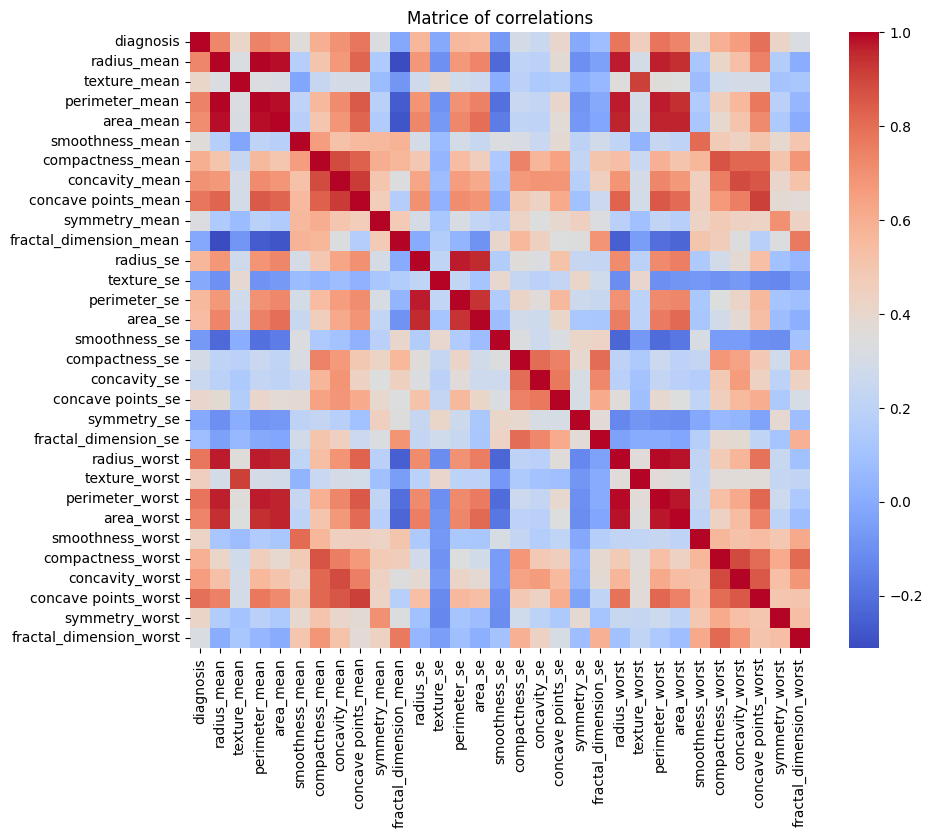

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load the data
df=pd.read_csv('Cancer_Data.csv')

#----EXPLORATION----
print ("----View the first few rows of the data---- \n")
print (df.head())
print("\n----informations about rows and columns----\n")
print(df.info())
#----CLEANING----

#Delete column ID and unnamded (Useless for the diagnosis)

df=df.drop(['id'],axis=1,errors='ignore')
df=df.drop(['Unnamed: 32'],axis=1,errors='ignore')

#Transform M into 1 AND B to 0
df['diagnosis']=df['diagnosis'].map({'M':1,'B':0})

#Verification if a value is missing in a column
print("\n Values which are missing per column")
print(df.isnull().sum())

print("\n----Informations after cleaning----\n")
print(df.info)

#----VISUALISATION----

plt.figure(figsize=(10,8))
sns.heatmap(df.corr(), annot=False, cmap='coolwarm')
plt.title("Matrice of correlations")
plt.show

print("\nCleaning finished . Data are ready for training")



In [3]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# 1. Separating the data
X = df.drop('diagnosis', axis=1)
y = df['diagnosis']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 2. Initialization of the scaler
scaler = StandardScaler()

# 3. We learn the average/standart deviation just on the train
scaler.fit(X_train)

# 4. Transform TRAIN and  TEST with the same parameters
X_train_scaled = scaler.transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Data  normalized with success !")


Data  normalized with success !


--- Statistics after normalization ---
      radius_mean  texture_mean  perimeter_mean  area_mean  smoothness_mean  \
mean         -0.0          -0.0            -0.0        0.0             -0.0   
std           1.0           1.0             1.0        1.0              1.0   

      compactness_mean  concavity_mean  concave points_mean  symmetry_mean  \
mean              -0.0            -0.0                  0.0            0.0   
std                1.0             1.0                  1.0            1.0   

      fractal_dimension_mean  ...  radius_worst  texture_worst  \
mean                     0.0  ...          -0.0           -0.0   
std                      1.0  ...           1.0            1.0   

      perimeter_worst  area_worst  smoothness_worst  compactness_worst  \
mean             -0.0         0.0              -0.0               -0.0   
std               1.0         1.0               1.0                1.0   

      concavity_worst  concave points_worst  symmetry_worst  \
mea

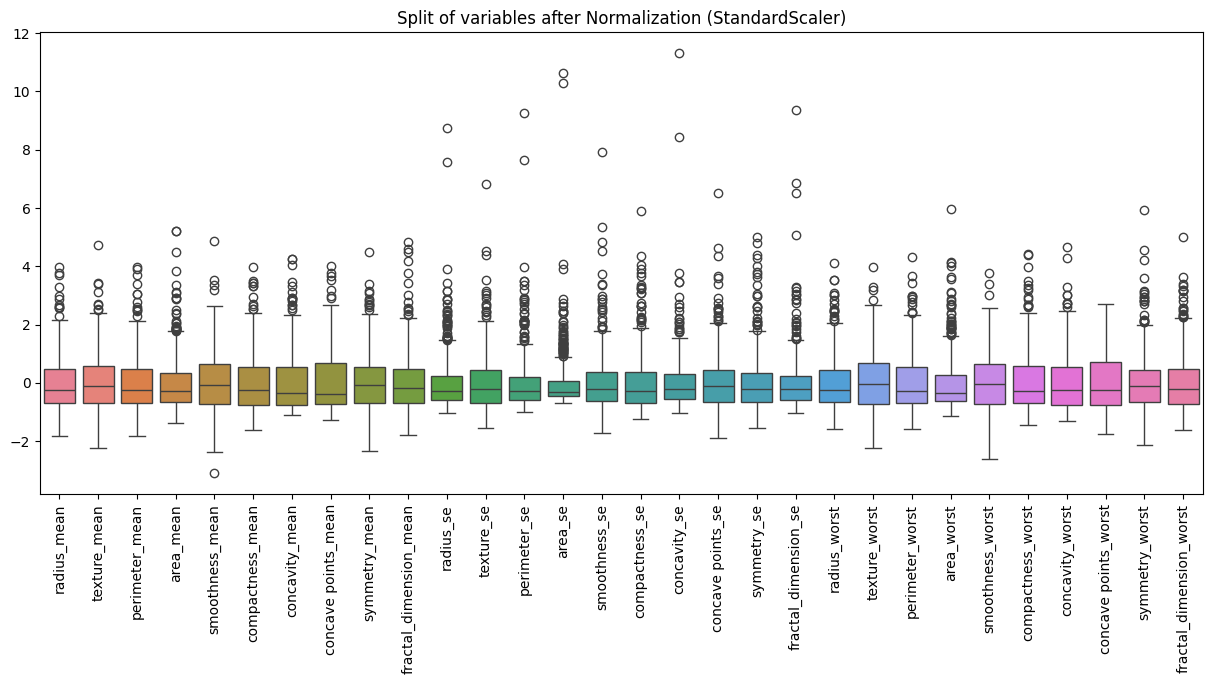

In [4]:

# 1. Convertion of the result(which is a an array numpy) into a DataFrame Pandas
# We use the same name of columns
X_train_scaled_df = pd.DataFrame(X_train_scaled, columns=X.columns)

# 2.  Display statistics
print("--- Statistics after normalization ---")
# We use  .round(2) for the legibility
print(X_train_scaled_df.describe().loc[['mean', 'std']].round(2))

# 3. Visualisation : Boxplot
# Cela permet de voir si les données sont bien centrées autour de 0
plt.figure(figsize=(15, 6))
sns.boxplot(data=X_train_scaled_df)
plt.xticks(rotation=90)
plt.title("Split of variables after Normalization (StandardScaler)")
plt.show()

In [5]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

# 1. Initialization of the model
model = RandomForestClassifier(n_estimators=100, random_state=42)

# 2. Training of the model (it will lean relation between features)
model.fit(X_train_scaled, y_train)

# 3. Prédiction ( the meodel will imagine  diagnostics on data of the  test)
y_pred = model.predict(X_test_scaled)

In [6]:
# Affichage des résultats
print("Global accuracy : {:.2f}%".format(accuracy_score(y_test, y_pred) * 100))

print("\n--- Matrice of Confusion ---")
print(confusion_matrix(y_test, y_pred))

print("\n--- Comprehensive Report ---")
print(classification_report(y_test, y_pred))

Global accuracy : 96.49%

--- Matrice of Confusion ---
[[70  1]
 [ 3 40]]

--- Comprehensive Report ---
              precision    recall  f1-score   support

           0       0.96      0.99      0.97        71
           1       0.98      0.93      0.95        43

    accuracy                           0.96       114
   macro avg       0.97      0.96      0.96       114
weighted avg       0.97      0.96      0.96       114

